# Linear SVM from Scratch: Soft-Margin, Primal Hinge Loss with L2 Regularisation, Stochastic Subgradient Descent

**Course:** 32513 Advanced Data Analytics Algorithms, Assessment 2 (Option 1: one fundamental model, implemented from scratch and studied in depth).

**Author:** Abraham Wilson (Student ID 26238016)

**Task:** decide whether a loan application is approved or rejected from the applicant's financial profile (binary classification).

**Data:** Kaggle "Loan Approval Prediction Dataset" (`architsharma01/loan-approval-prediction-dataset`): 4,269 applications, 11 input features, target `loan_status`.

**Model:** a linear soft-margin support vector machine, written in NumPy and trained on the primal objective (an L2 penalty plus `C` times the mean hinge loss) with stochastic subgradient descent, one training row at a time.

## 1. Environment Setup

The first cell installs the required packages on a fresh cloud runtime. It is commented out by default: uncomment it and run it once on Colab. The second cell imports everything used in the notebook. `train_test_split` (Section 4.1) takes its own seed, so the split and every later result are reproducible.

In [27]:
# Cell 1 — environment setup (run first, once)
# %pip install -q scikit-learn==1.5.2 pandas==2.2.* matplotlib==3.8.* kagglehub

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.typing import NDArray

## 2. Load and Inspect the Data

### 2.1 Loading

The dataset is downloaded from Kaggle with `kagglehub`, so the notebook needs no local files. Each row is one loan application: 11 input features describing the applicant and the loan, and the outcome `loan_status` (Approved or Rejected).

In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(Path(path) / "loan_approval_dataset.csv")

Path to dataset files: C:\Users\awils\.cache\kagglehub\datasets\architsharma01\loan-approval-prediction-dataset\versions\1


### 2.2 Cleaning

Checks run on the raw data, and the decision each one led to:

| Check | Finding | Decision |
|---|---|---|
| Whitespace | Every column name except `loan_id`, and every text value, has a leading space in the raw file | Stripped (otherwise `df["education"]` raises a `KeyError`) |
| Missing values | None | Nothing to remove |
| Duplicate rows | None | Nothing to remove |
| `loan_id` | Unique per row, so it is only a label | Dropped |
| Text columns | `education`, `self_employed` and `loan_status` are strings | Encoded as 0/1: Graduate = 1, Yes = 1, Approved = 1. The labels are converted to {-1, +1} for the SVM in Section 4 |
| Physical validity | Income, loan amount and loan term are positive; `cibil_score` lies within 300-900 | All pass, nothing to remove |
| Negative asset values | 28 rows (0.7%) have `residential_assets_value` = -100,000, an impossible value repeated identically, which looks like a placeholder | Kept and flagged: it is under 1% of rows and the feature has almost no linear relationship with the outcome (Section 2.5). Dropping them would also be defensible |
| Outliers | Skew is at most about 1 (the asset columns) | None removed |

In [30]:
df_loan = df.copy()
df_loan.columns = df_loan.columns.str.strip()
text_cols = df_loan.select_dtypes(include="object").columns
df_loan[text_cols] = df_loan[text_cols].apply(lambda s: s.str.strip())

print(f"Missing values: {int(df_loan.isnull().sum().sum())}")
assert df_loan["loan_id"].is_unique
df_loan = df_loan.drop(columns="loan_id")
print(f"Duplicate rows (ignoring loan_id): {int(df_loan.duplicated().sum())}")

encodings = {
    "education": {"Not Graduate": 0, "Graduate": 1},
    "self_employed": {"No": 0, "Yes": 1},
    "loan_status": {"Rejected": 0, "Approved": 1},
}
for col, mapping in encodings.items():
    df_loan[col] = df_loan[col].map(mapping)
    assert df_loan[col].notna().all(), f"unexpected value in {col}"

violations = {
    "income_annum <= 0": int((df_loan["income_annum"] <= 0).sum()),
    "loan_amount <= 0": int((df_loan["loan_amount"] <= 0).sum()),
    "loan_term <= 0": int((df_loan["loan_term"] <= 0).sum()),
    "cibil_score outside 300-900": int((~df_loan["cibil_score"].between(300, 900)).sum()),
}
print("Sanity-check violations:", violations)
assert sum(violations.values()) == 0

asset_cols = ["residential_assets_value", "commercial_assets_value", "luxury_assets_value", "bank_asset_value"]
negatives = {col: int((df_loan[col] < 0).sum()) for col in asset_cols}
print("Rows with a negative asset value:", {col: n for col, n in negatives.items() if n})
print("Distinct negative values:", sorted(df_loan.loc[df_loan["residential_assets_value"] < 0, "residential_assets_value"].unique().tolist()))

print(f"\nCleaned shape: {df_loan.shape}")
print(df_loan.dtypes.to_string())

Missing values: 0
Duplicate rows (ignoring loan_id): 0
Sanity-check violations: {'income_annum <= 0': 0, 'loan_amount <= 0': 0, 'loan_term <= 0': 0, 'cibil_score outside 300-900': 0}
Rows with a negative asset value: {'residential_assets_value': 28}
Distinct negative values: [-100000]

Cleaned shape: (4269, 12)
no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64


### 2.3 Summary statistics

Two observations from the table below shape the rest of the notebook.

**The rows are independent.** Every `loan_id` was unique, no two applications are identical, and nothing links one row to another. A plain stratified split, and stratified 5-fold cross-validation, are therefore enough. The course FAQ's warning to "split by group" concerns the same subject appearing in several rows, which does not happen here.

**The features are on very different scales.** Compare the `min` and `max` columns: `education` is 0/1, `cibil_score` runs from 300 to 900, and `loan_amount` reaches tens of millions. The SVM's margin is a geometric distance, so the large-scale features would dominate it unless the features are standardised (Section 4.2).

In [31]:
feature_cols = [c for c in df_loan.columns if c != "loan_status"]

summary = df_loan[feature_cols].describe().T
summary["skew"] = df_loan[feature_cols].skew()
summary.map("{:,.2f}".format)

,count,mean,std,min,25%,50%,75%,max,skew
no_of_dependents,"4,269.00",2.50,1.70,0.00,1.00,3.00,4.00,5.00,-0.02
education,"4,269.00",0.50,0.50,0.00,0.00,1.00,1.00,1.00,-0.01
self_employed,"4,269.00",0.50,0.50,0.00,0.00,1.00,1.00,1.00,-0.01
income_annum,"4,269.00","5,059,123.92","2,806,839.83","200,000.00","2,700,000.00","5,100,000.00","7,500,000.00","9,900,000.00",-0.01
loan_amount,"4,269.00","15,133,450.46","9,043,362.98","300,000.00","7,700,000.00","14,500,000.00","21,500,000.00","39,500,000.00",0.31
loan_term,"4,269.00",10.90,5.71,2.00,6.00,10.00,16.00,20.00,0.04
cibil_score,"4,269.00",599.94,172.43,300.00,453.00,600.00,748.00,900.00,-0.01
residential_assets_value,"4,269.00","7,472,616.54","6,503,636.59","-100,000.00","2,200,000.00","5,600,000.00","11,300,000.00","29,100,000.00",0.98
commercial_assets_value,"4,269.00","4,973,155.31","4,388,966.09",0.00,"1,300,000.00","3,700,000.00","7,600,000.00","19,400,000.00",0.96
luxury_assets_value,"4,269.00","15,126,305.93","9,103,753.67","300,000.00","7,500,000.00","14,600,000.00","21,700,000.00","39,200,000.00",0.32


### 2.4 Target distribution

The classes are mildly imbalanced (about 62% Approved). The majority-class rate is therefore the baseline any model has to beat, and the train/test split must preserve the class ratio (Section 4.1).

              count   share
0 (Rejected)   1613  0.3778
1 (Approved)   2656  0.6222
Imbalance ratio (Approved : Rejected) = 1.65 : 1


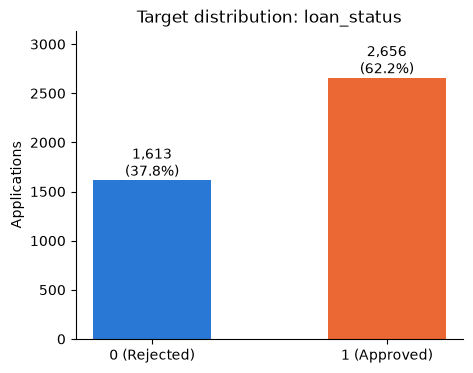

In [32]:
CLASS_COLORS = ["#2a78d6", "#eb6834"]  # class 0, class 1 (fixed order, reused for every class-coloured plot)
CLASS_NAMES = ["0 (Rejected)", "1 (Approved)"]

counts = df_loan["loan_status"].value_counts().sort_index()
share = counts / counts.sum()
print(pd.DataFrame({"count": counts.values, "share": share.round(4).values}, index=CLASS_NAMES).to_string())
print(f"Imbalance ratio (Approved : Rejected) = {counts[1] / counts[0]:.2f} : 1")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(CLASS_NAMES, counts.values, color=CLASS_COLORS, width=0.5)
for bar, n, s in zip(bars, counts.values, share.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{n:,}\n({s:.1%})", ha="center", va="bottom")
ax.set_ylabel("Applications")
ax.set_title("Target distribution: loan_status")
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### 2.5 Pearson correlation matrix

Pearson measures *linear* association only, so a strong non-linear relationship can look weak here. The matrix is read in two ways: each feature's correlation with the target, and the correlation between features. Strongly correlated features carry overlapping information, and a linear model splits its weight between them.

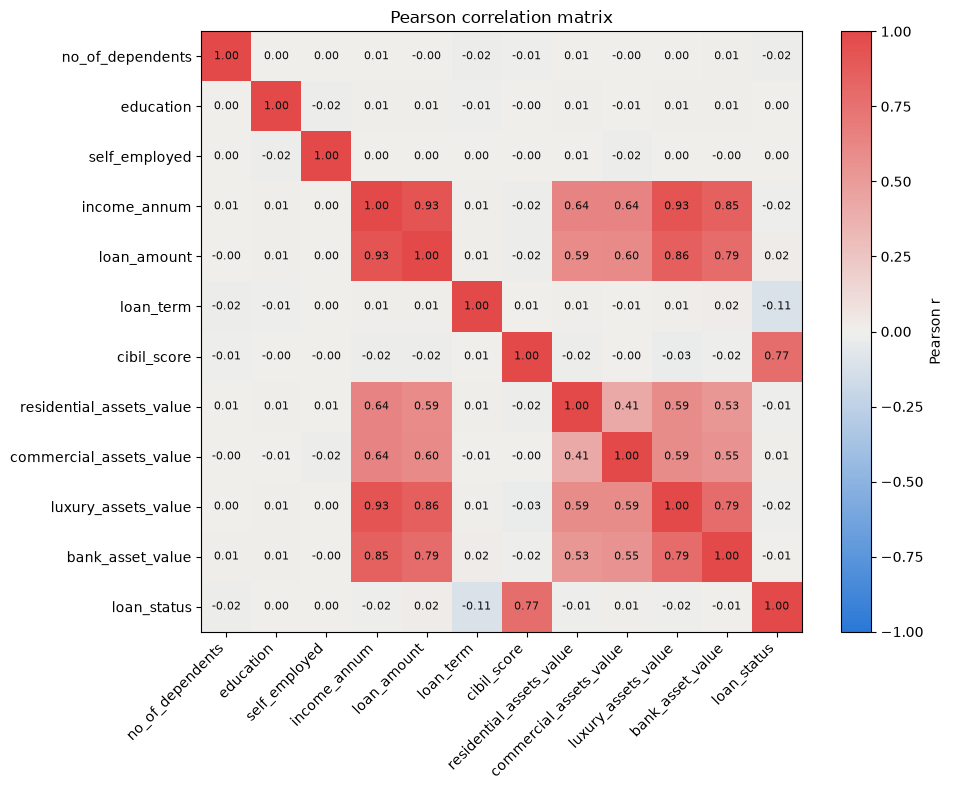

Correlation with the target (loan_status), sorted by |r|:
cibil_score                 0.771
loan_term                  -0.113
no_of_dependents           -0.018
loan_amount                 0.016
luxury_assets_value        -0.015
income_annum               -0.015
residential_assets_value   -0.014
commercial_assets_value     0.008
bank_asset_value           -0.007
education                   0.005
self_employed               0.000

Feature pairs with |r| > 0.7:
income_annum         luxury_assets_value    0.93
                     loan_amount            0.93
loan_amount          luxury_assets_value    0.86
income_annum         bank_asset_value       0.85
luxury_assets_value  bank_asset_value       0.79
loan_amount          bank_asset_value       0.79


In [33]:
from matplotlib.colors import LinearSegmentedColormap

diverging = LinearSegmentedColormap.from_list("blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"])

corr_cols = feature_cols + ["loan_status"]
corr = df_loan[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), labels=corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), labels=corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="#0b0b0b")
fig.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

print("Correlation with the target (loan_status), sorted by |r|:")
print(corr["loan_status"].drop("loan_status").sort_values(key=abs, ascending=False).round(3).to_string())

upper = np.triu(np.ones((len(feature_cols), len(feature_cols)), dtype=bool), k=1)
pairs = corr.loc[feature_cols, feature_cols].where(upper).stack()
print("\nFeature pairs with |r| > 0.7:")
print(pairs[pairs.abs() > 0.7].sort_values(key=abs, ascending=False).round(2).to_string())

## 4. Preprocessing

Three steps, in this order:

1. **Labels.** The SVM needs labels in {-1, +1}, so `loan_status` (0/1) becomes `y = 2 * loan_status - 1`: Approved = +1, Rejected = -1.
2. **Train/test split.** 80% train, 20% test, stratified on the label so both parts keep the same Approved share, with `random_state=42`. The split comes *before* standardisation so that nothing about the test set leaks into training.
3. **Standardisation.** Each feature is rescaled to mean 0 and standard deviation 1 using the **training set's** mean and standard deviation only. The same two numbers are then applied to the test set.

### 4.1 Labels and stratified train/test split

In [34]:
def train_test_split(
    X: NDArray[np.float64],
    y: NDArray[np.float64],
    test_size: float = 0.2,
    seed: int | None = None
) -> tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64], NDArray[np.float64]]:
    """
    Stratified train-test split for NumPy arrays.
    
    Guarantees that class proportions in y_train and y_test match y.
    """
    if not (0.0 < test_size < 1.0):
        raise ValueError("test_size must be strictly between 0 and 1.")

    # 1. Create seeded default_rng generator
    rng = np.random.default_rng(seed)

    # Identify all distinct classes
    unique_classes, counts = np.unique(y, return_counts=True)


    train_indices_list: list[NDArray[np.int_]] = []
    test_indices_list: list[NDArray[np.int_]] = []

    # 2. Stratified splitting per class
    for cls, count in zip(unique_classes, counts):
        # Extract row indices for current class
        cls_indices: NDArray[np.int_] = np.where(y == cls)[0]
        
        # Shuffle class indices
        rng.shuffle(cls_indices)
        
        # Compute exact test slice for this class
        n_test: int = int(round(test_size * count))

        
        # Guarantee at least 1 sample per split if class has >= 2 samples
        if n_test == 0 and count >= 2:
            n_test = 1
        elif n_test == count and count >= 2:
            n_test = count - 1

        # Partition into test and train sets
        test_indices_list.append(cls_indices[:n_test])
        train_indices_list.append(cls_indices[n_test:])

    # 3. Concatenate all per-class index arrays
    train_indices: NDArray[np.int_] = np.concatenate(train_indices_list)
    test_indices: NDArray[np.int_] = np.concatenate(test_indices_list)

    # 4. Shuffle combined indices to prevent ordered class blocks
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    # 5. Extract joint feature and target splits
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

In [35]:
X = df_loan[feature_cols].to_numpy(dtype=float)
y = 2 * df_loan["loan_status"].to_numpy() - 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, seed=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Approved (+1) share: train {np.mean(y_train == 1):.3f}, test {np.mean(y_test == 1):.3f}")

[-1  1] [1613 2656]
323 0.2 1613
531 0.2 2656
Train: (3415, 11), Test: (854, 11)
Approved (+1) share: train 0.622, test 0.622


### 4.2 Standardisation

The SVM's margin is a geometric distance, so a feature measured in the millions would dominate one measured in single digits. Standardising puts every feature on the same footing: $x_{\text{std}} = (x - \mu_{\text{train}}) / \sigma_{\text{train}}$.

The mean $\mu$ and standard deviation $\sigma$ come from the training set only. Computing them on all the data would let information from the test set influence training, which inflates the test score. Cross-validation has to repeat this inside every fold for the same reason.

In [36]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
assert (sigma > 0).all(), "a constant feature cannot be standardised"

X_train_std = (X_train - mu) / sigma
X_test_std = (X_test - mu) / sigma

print(f"Train mean per feature: max |mean| = {np.abs(X_train_std.mean(axis=0)).max():.1e}")
print(f"Train std per feature:  min {X_train_std.std(axis=0).min():.3f}, max {X_train_std.std(axis=0).max():.3f}")
print(f"Test mean per feature:  max |mean| = {np.abs(X_test_std.mean(axis=0)).max():.3f} (not exactly 0: the test set is scaled with the training statistics)")

Train mean per feature: max |mean| = 4.0e-16
Train std per feature:  min 1.000, max 1.000
Test mean per feature:  max |mean| = 0.092 (not exactly 0: the test set is scaled with the training statistics)


## 5. The Model: Loss and Subgradient

The **loss** measures how far the model's predictions are from the targets. Because this is classification, only points that are misclassified, or that sit too close to the boundary, should be penalised. That is what the hinge loss does. The **gradient** says how the weights should change to reduce the loss. The hinge loss has a kink where a point sits exactly on the margin, so there the gradient is taken as a *subgradient*.

In [ ]:
def compute_loss(w, b, X, y, C) -> float:
    scores = X @ w + b
    margins = y * scores

    slack = np.maximum(0, 1 - margins)
    loss = 0.5 * np.dot(w, w) + C * np.mean(slack)
    
    return loss

In [ ]:
def train_svm(X: NDArray[np.float64], 
              y: NDArray[np.float64], 
              C: float, 
              lr: float, 
              epochs: int, 
              shuffle=True, 
              seed: int = 42):
    n_samples, n_features = X.shape
    w: NDArray[np.float64] = np.zeros(n_features)
    b: float = 0.0
    y_: NDArray[np.float64] = np.where(y <= 0, -1.0, 1.0)

    indices: NDArray[np.int_] = np.arange(n_samples)
    rng: np.random.Generator = np.random.default_rng(seed)
    loss_hist = []

    for _ in range(epochs):

        if shuffle:
            rng.shuffle(indices)

        for i in indices:
            x_i: NDArray[np.float64] = X[i]
            y_i: float = float(y_[i])

            score = x_i @ w + b
            margin = y_i * score
            if margin >= 1.0:
                w = w - (lr * w)
            else:
                w = w - lr * (w - C * y_i * x_i)
                b = b + lr * C * y_i

        loss_hist.append(compute_loss(w, b, X, y_, C))

    return (w, b, loss_hist)

In [39]:
def predict(w: NDArray[np.float64], b: float, X: NDArray[np.float64]):
    scores = X @ w + b
    return np.where(scores >= 0, 1.0, -1.0)

In [40]:
def accuracy(
    y_true: NDArray[np.float64], # 1D array of shape (n_samples,)
    y_pred: NDArray[np.float64]  # 1D array of shape (n_samples,)
) -> float:
    """
    Calculates the classification accuracy (fraction of matching positions).
    """
    # Compare element-wise (boolean array) and compute the mean scalar
    return float(np.mean(y_true == y_pred))

In [ ]:
def confusion_matrix(
    y_true: NDArray[np.float64], # 1D array of shape (n_samples,)
    y_pred: NDArray[np.float64]  # 1D array of shape (n_samples,)
) -> NDArray[np.int64]:
    """
    Computes a 2x2 confusion matrix:
    
            Pred -1    Pred +1
    True -1 [  TN        FP   ]
    True +1 [  FN        TP   ]
    """
    # Boolean masks for true class conditions
    is_neg: NDArray[np.bool_] = (y_true == -1.0)
    is_pos: NDArray[np.bool_] = (y_true == 1.0)

    # Calculate count scalars
    tn: int = int(np.sum(is_neg & (y_pred == -1.0)))
    fp: int = int(np.sum(is_neg & (y_pred == 1.0)))
    fn: int = int(np.sum(is_pos & (y_pred == -1.0)))
    tp: int = int(np.sum(is_pos & (y_pred == 1.0)))

    # Return structured 2x2 array
    return np.array([
        [tn, fp],
        [fn, tp]
    ], dtype=np.int64)

### Ranking metrics: ROC-AUC and average precision

Accuracy depends on where the decision threshold sits (score >= 0), so it mixes two things: how well the scores rank Approved applications above Rejected ones, and whether zero is the right cut-off. ROC-AUC and average precision (AP) look at the ranking only, by sliding the threshold across every score. ROC-AUC is the probability that a random Approved application scores higher than a random Rejected one (0.5 is chance, 1 is a perfect ranking). AP averages precision over the steps in recall, and its chance level is the share of Approved applications (about 0.62 here). Both treat Approved (+1) as the positive class.

In [42]:
def decision_scores(
    w: NDArray[np.float64],
    b: float,
    X: NDArray[np.float64]
) -> NDArray[np.float64]:
    """
    Raw score w.x_i + b for every row, before thresholding at 0.
    predict() is the sign of this score.
    """
    return X @ w + b

In [43]:
def roc_curve(
    y_true: NDArray[np.float64],  # 1D array of shape (n_samples,), labels in {-1, +1}
    scores: NDArray[np.float64]   # 1D array of shape (n_samples,), higher = more likely +1
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """
    ROC curve for the positive class (+1): false-positive rate and true-positive rate
    as the threshold slides from above the highest score down to below the lowest.
    """
    is_pos: NDArray[np.bool_] = (y_true == 1)
    n_pos: int = int(np.sum(is_pos))
    n_neg: int = len(y_true) - n_pos
    if n_pos == 0 or n_neg == 0:
        raise ValueError("ROC needs at least one +1 and one -1 example.")

    # Walk down the rows from the highest score to the lowest
    order = np.argsort(-scores, kind="stable")
    sorted_scores = scores[order]
    sorted_pos = is_pos[order]

    # Running counts of +1 rows (tp) and -1 rows (fp) at or above each row's score
    tp = np.cumsum(sorted_pos)
    fp = np.cumsum(~sorted_pos)

    # Rows that share a score share one threshold, so keep only the last row of each run of ties
    last_of_run = np.append(np.flatnonzero(np.diff(sorted_scores)), len(scores) - 1)

    # Start at (0, 0): a threshold above every score predicts nothing
    tpr = np.concatenate(([0.0], tp[last_of_run] / n_pos))
    fpr = np.concatenate(([0.0], fp[last_of_run] / n_neg))
    return fpr, tpr


def auc(x: NDArray[np.float64], y: NDArray[np.float64]) -> float:
    """Area under a curve by the trapezoid rule: the sum of (width * average height)."""
    return float(np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2.0))


def roc_auc(y_true: NDArray[np.float64], scores: NDArray[np.float64]) -> float:
    """
    ROC-AUC: the probability that a random +1 row scores higher than a random -1 row
    (ties count half). 0.5 is chance, 1.0 is a perfect ranking.
    """
    fpr, tpr = roc_curve(y_true, scores)
    return auc(fpr, tpr)

In [44]:
def precision_recall_curve(
    y_true: NDArray[np.float64],  # 1D array of shape (n_samples,), labels in {-1, +1}
    scores: NDArray[np.float64]   # 1D array of shape (n_samples,), higher = more likely +1
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """
    Precision-recall curve for the positive class (+1), one point per distinct threshold,
    from the highest threshold down.
    """
    is_pos: NDArray[np.bool_] = (y_true == 1)
    n_pos: int = int(np.sum(is_pos))
    if n_pos == 0:
        raise ValueError("Precision-recall needs at least one +1 example.")

    # Walk down the rows from the highest score to the lowest
    order = np.argsort(-scores, kind="stable")
    sorted_scores = scores[order]
    sorted_pos = is_pos[order]

    tp = np.cumsum(sorted_pos)                       # +1 rows at or above each row's score
    n_predicted_pos = np.arange(1, len(scores) + 1)  # all rows at or above it are predicted +1

    # Rows that share a score share one threshold, so keep only the last row of each run of ties
    last_of_run = np.append(np.flatnonzero(np.diff(sorted_scores)), len(scores) - 1)

    # Start at recall 0 with precision 1 by convention (nothing predicted yet)
    recall = np.concatenate(([0.0], tp[last_of_run] / n_pos))
    precision = np.concatenate(([1.0], tp[last_of_run] / n_predicted_pos[last_of_run]))
    return recall, precision


def average_precision(y_true: NDArray[np.float64], scores: NDArray[np.float64]) -> float:
    """
    Average precision: the sum over thresholds of (increase in recall) * (precision there).
    A step sum rather than a trapezoid, because precision does not change linearly between points.
    """
    recall, precision = precision_recall_curve(y_true, scores)
    return float(np.sum(np.diff(recall) * precision[1:]))

In [45]:
# 1. Define C sweep array extending up to 10,000
C_sweep = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]

# Dictionary to store results for each C
results = {}

# 2. Iterate through C_sweep
for C in C_sweep:
    w, b, loss_hist = train_svm(
        X=X_train_std, 
        y=y_train, 
        C=C, 
        lr=0.003 / C, 
        epochs=10,
        shuffle=True
    )
    
    # Predict
    y_pred_train = predict(w, b, X_train_std)
    y_pred_test = predict(w, b, X_test_std)
    
    # Calculate metrics
    train_acc = accuracy(y_train, y_pred_train)
    test_acc = accuracy(y_test, y_pred_test)
    cm = confusion_matrix(y_test, y_pred_test)

    # Threshold-free ranking metrics on the raw test scores
    test_scores = decision_scores(w, b, X_test_std)
    test_roc_auc = roc_auc(y_test, test_scores)
    test_ap = average_precision(y_test, test_scores)
    
    # Save run data
    results[C] = {
        'w': w,
        'b': b,
        'loss_hist': loss_hist,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'confusion_matrix': cm,
        'test_scores': test_scores,
        'test_roc_auc': test_roc_auc,
        'test_ap': test_ap
    }
    
    # Print summary per run
    print(f"C={C:<8} | Final Loss: {loss_hist[-1]:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Test ROC-AUC: {test_roc_auc:.4f} | Test AP: {test_ap:.4f}")

    # Test-set confusion matrix: rows = true class, columns = predicted class
    print(pd.DataFrame(cm, index=["True -1", "True +1"], columns=["Pred -1", "Pred +1"]).to_string())
    print()



C=0.01     | Final Loss: 25.8431 | Train Acc: 0.6223 | Test Acc: 0.6218 | Test ROC-AUC: 0.6322 | Test AP: 0.7382
         Pred -1  Pred +1
True -1        0      323
True +1        0      531

C=0.1      | Final Loss: 251.8654 | Train Acc: 0.6223 | Test Acc: 0.6218 | Test ROC-AUC: 0.9166 | Test AP: 0.9481
         Pred -1  Pred +1
True -1        0      323
True +1        0      531

C=1.0      | Final Loss: 1907.6380 | Train Acc: 0.7192 | Test Acc: 0.6991 | Test ROC-AUC: 0.9574 | Test AP: 0.9765
         Pred -1  Pred +1
True -1       75      248
True +1        9      522

C=10.0     | Final Loss: 9893.0934 | Train Acc: 0.9268 | Test Acc: 0.9215 | Test ROC-AUC: 0.9610 | Test AP: 0.9781
         Pred -1  Pred +1
True -1      290       33
True +1       34      497

C=100.0    | Final Loss: 76802.5885 | Train Acc: 0.9306 | Test Acc: 0.9251 | Test ROC-AUC: 0.9627 | Test AP: 0.9788
         Pred -1  Pred +1
True -1      295       28
True +1       36      495

C=1000.0   | Final Loss: 734903.

### Reference implementation: scikit-learn SVC

As a check on the implementation above, scikit-learn's `SVC(kernel="linear")` is fitted on the same standardised training data. It is used for comparison only, never inside the model. It solves the same soft-margin objective, but scikit-learn applies `C` to the *sum* of the slacks while this notebook applies it to their *mean*, so the two are related by `C_sklearn = C / n_train`. The sweep below uses the same grid as before, converted with that factor, so every row compares the same objective. The best `C` for the standard implementation is the one with the highest training accuracy (the smallest `C` if tied), so the test set plays no part in the choice.

In [ ]:
# Reference only: scikit-learn is never used by the model above
from sklearn.svm import SVC

n_train = X_train_std.shape[0]
sk_results = {}

for C in C_sweep:
    # scikit-learn puts C on the SUM of the slacks, ours on the MEAN: C_sklearn = C_ours / n_train
    sk_C = C / n_train

    model = SVC(C=sk_C, kernel="linear").fit(X_train_std, y_train)
    test_scores = model.decision_function(X_test_std)  # positive side = +1 (Approved)

    sk_results[C] = {
        "sk_C": sk_C,
        "train_acc": accuracy(y_train, model.predict(X_train_std)),
        "test_acc": accuracy(y_test, model.predict(X_test_std)),
        "test_scores": test_scores,
        "test_roc_auc": roc_auc(y_test, test_scores),
        "test_ap": average_precision(y_test, test_scores),
    }

# Best C for the standard implementation: highest training accuracy (the smallest C if tied)
best_C = max(C_sweep, key=lambda C: sk_results[C]["train_acc"])

# Ours and scikit-learn side by side at the same C
print(pd.DataFrame({
    "C (ours)": C_sweep,
    "C (sklearn)": [f"{sk_results[C]['sk_C']:.3g}" for C in C_sweep],
    "Train acc (sklearn)": [sk_results[C]["train_acc"] for C in C_sweep],
    "Test acc (ours)": [results[C]["test_acc"] for C in C_sweep],
    "Test acc (sklearn)": [sk_results[C]["test_acc"] for C in C_sweep],
    "ROC-AUC (ours)": [results[C]["test_roc_auc"] for C in C_sweep],
    "ROC-AUC (sklearn)": [sk_results[C]["test_roc_auc"] for C in C_sweep],
}).round(4).to_string(index=False))
print(f"\nBest C for the standard implementation (highest training accuracy): "
      f"C={best_C:g} (sklearn C={sk_results[best_C]['sk_C']:.3g})")

### ROC and precision-recall curves across C

Each blue curve is our implementation at one value of C, drawn from the raw test scores (`decision_scores`). C is an ordered quantity, so the colour runs from light (small C) to dark (large C). The dashed orange curve is scikit-learn's SVC at its best C, chosen on the training set, so the two implementations can be compared on the same axes. A curve closer to the top-left corner (ROC) or the top-right corner (precision-recall) ranks the applications better. The grey dashed lines mark chance level: the diagonal for ROC, and the share of Approved applications for precision-recall.

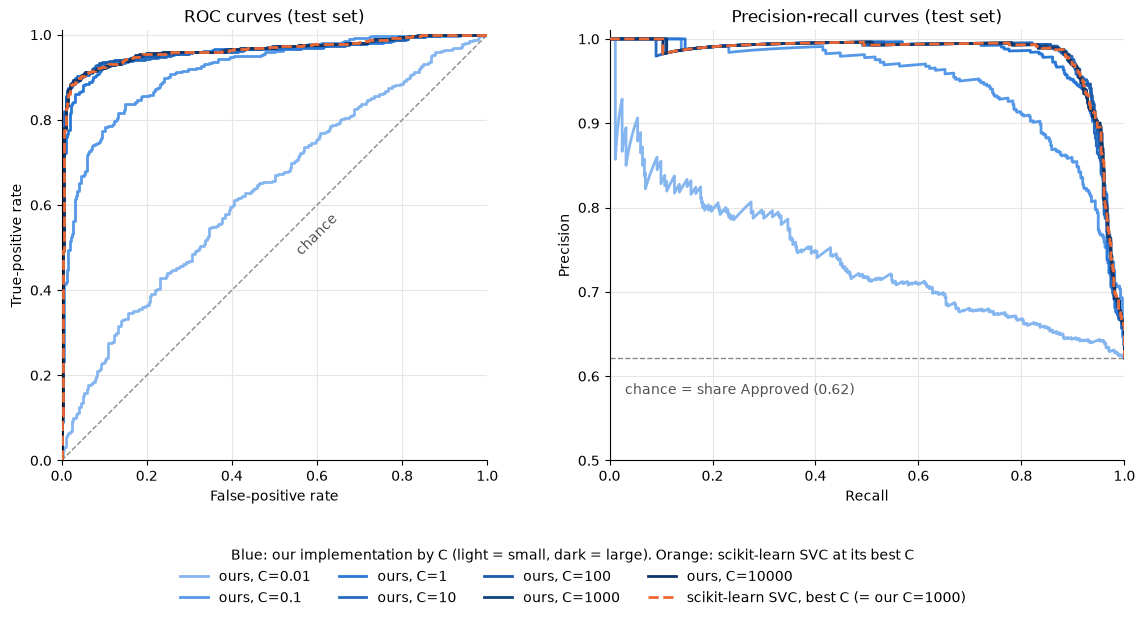

                   Model  Test ROC-AUC  Test AP
            ours, C=0.01        0.6322   0.7382
             ours, C=0.1        0.9166   0.9481
               ours, C=1        0.9574   0.9765
              ours, C=10        0.9610   0.9781
             ours, C=100        0.9627   0.9788
            ours, C=1000        0.9628   0.9789
           ours, C=10000        0.9625   0.9786
scikit-learn SVC, best C        0.9627   0.9786


In [47]:
# One blue hue for C (an ordered quantity): light = small C, dark = large C
C_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#256abf", "#1c5cab", "#104281", "#0d366b"]
C_COLOR = dict(zip(C_sweep, C_RAMP))
SK_COLOR = "#eb6834"  # contrasting hue for the standard (scikit-learn) implementation

test_prevalence = np.mean(y_test == 1)
min_precision = 1.0

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 6.4))

for C in C_sweep:
    test_scores = results[C]["test_scores"]
    fpr, tpr = roc_curve(y_test, test_scores)
    recall, precision = precision_recall_curve(y_test, test_scores)
    ax_roc.plot(fpr, tpr, color=C_COLOR[C], linewidth=2, label=f"ours, C={C:g}")
    ax_pr.plot(recall, precision, color=C_COLOR[C], linewidth=2)
    min_precision = min(min_precision, precision.min())

# The standard implementation at its best C, dashed and drawn on top so it stays visible over our curves
sk_scores = sk_results[best_C]["test_scores"]
sk_fpr, sk_tpr = roc_curve(y_test, sk_scores)
sk_recall, sk_precision = precision_recall_curve(y_test, sk_scores)
ax_roc.plot(sk_fpr, sk_tpr, color=SK_COLOR, linewidth=2, linestyle="--", zorder=3,
            label=f"scikit-learn SVC, best C (= our C={best_C:g})")
ax_pr.plot(sk_recall, sk_precision, color=SK_COLOR, linewidth=2, linestyle="--", zorder=3)
min_precision = min(min_precision, sk_precision.min())

# Chance level: the diagonal for ROC, the share of Approved for precision-recall
ax_roc.plot([0, 1], [0, 1], color="#8b8a86", linestyle="--", linewidth=1)
ax_pr.axhline(test_prevalence, color="#8b8a86", linestyle="--", linewidth=1)
ax_roc.text(0.60, 0.53, "chance", color="#52514e", rotation=45, ha="center", va="center")
ax_pr.text(0.03, test_prevalence - 0.03, f"chance = share Approved ({test_prevalence:.2f})", color="#52514e", va="top")

ax_roc.set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curves (test set)")
ax_pr.set(xlabel="Recall", ylabel="Precision", title="Precision-recall curves (test set)")
ax_roc.set_ylim(0, 1.01)
ax_roc.set_aspect("equal")
ax_pr.set_ylim(min(0.5, np.floor(min_precision * 20) / 20), 1.01)  # zoomed: precision rarely falls far below chance
for ax in (ax_roc, ax_pr):
    ax.set_xlim(0, 1)
    ax.grid(color="#e6e5e1", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

fig.legend(*ax_roc.get_legend_handles_labels(), loc="lower center", ncol=4, frameon=False,
           title="Blue: our implementation by C (light = small, dark = large). Orange: scikit-learn SVC at its best C")
fig.tight_layout(rect=(0, 0.15, 1, 0.97))
plt.show()

# Table view of the same information
rows = [(f"ours, C={C:g}", results[C]["test_roc_auc"], results[C]["test_ap"]) for C in C_sweep]
rows.append(("scikit-learn SVC, best C", sk_results[best_C]["test_roc_auc"], sk_results[best_C]["test_ap"]))
print(pd.DataFrame(rows, columns=["Model", "Test ROC-AUC", "Test AP"]).round(4).to_string(index=False))